# DATA 612 — Project 4: Accuracy and Beyond
**Zoran Glisovic**

**Dataset:** Last.fm hetrec-2011 (2K users) — [GroupLens / HetRec 2011](https://grouplens.org/datasets/hetrec-2011/)

This project compares two collaborative filtering algorithms on an implicit-feedback music dataset. It then implements three beyond-accuracy metrics — novelty, diversity, and serendipity (following the professor's approach in `metrics1.py`) — evaluates the accuracy–novelty tradeoff across multiple penalty levels, and proposes an online evaluation design.

## 1. Setup

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.sparse import csr_matrix                  # sparse matrix for the user-item matrix
from sklearn.metrics.pairwise import cosine_similarity  # for user-user and item-item similarity
import warnings
warnings.filterwarnings('ignore')

PALETTE = ['dodgerblue', 'orangered', 'mediumseagreen', 'mediumpurple']  # consistent color scheme across all charts
DATA = 'data/'                                           # relative path to the dataset folder

## 2. Data Loading & Exploration

The hetrec-2011 Last.fm dataset records how many times each user played each artist — **implicit feedback** rather than explicit ratings. There are no star scores; only raw listening counts (play counts).

Key files:
- `user_artists.dat` — (userID, artistID, weight) where weight is total play count
- `artists.dat` — artist names
- `user_taggedartists.dat` — user-applied tags per artist

In [178]:
ua = pd.read_csv(DATA + 'user_artists.dat', sep='\t')   # main interaction file: user-artist play counts
artists = pd.read_csv(DATA + 'artists.dat', sep='\t', on_bad_lines='skip', encoding='latin-1')[['id', 'name']]  # latin-1 for special characters in artist names
tags_df = pd.read_csv(DATA + 'user_taggedartists.dat', sep='\t', encoding='latin-1')  # user-applied genre tags

ua = ua.merge(artists, left_on='artistID', right_on='id').drop(columns='id')  # attach artist names to interactions

print(f"Users:        {ua.userID.nunique():,}")
print(f"Artists:      {ua.artistID.nunique():,}")
print(f"Interactions: {len(ua):,}")
print(f"Sparsity:     {1 - len(ua)/(ua.userID.nunique()*ua.artistID.nunique()):.4f}")  # fraction of matrix cells with no value
print(f"Play count — min: {ua.weight.min()}  median: {ua.weight.median():.0f}  max: {ua.weight.max():,}")

Users:        1,892
Artists:      17,632
Interactions: 92,834
Sparsity:     0.9972
Play count — min: 1  median: 260  max: 352,698


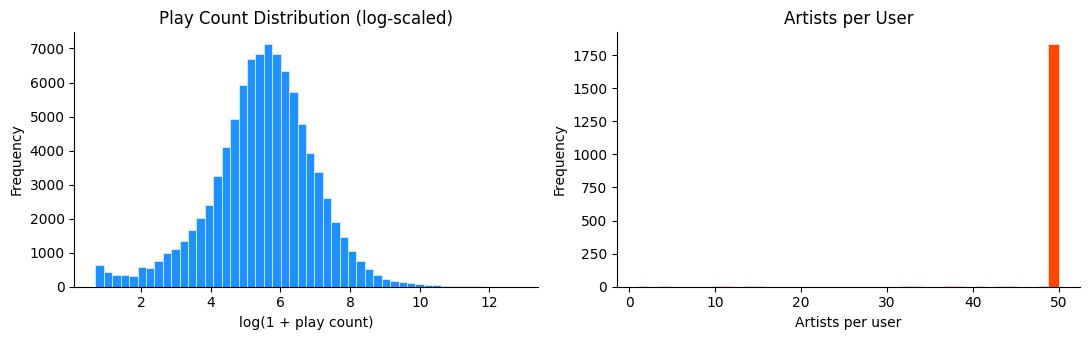

Median artists per user: 50   Max: 50


In [179]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# Play count distribution — log scale needed because range spans 5 orders of magnitude (1 to 352,698)
ax = axes[0]
ax.hist(np.log1p(ua['weight']), bins=50, color=PALETTE[0], edgecolor='white', linewidth=0.4)
ax.set_xlabel('log(1 + play count)')
ax.set_ylabel('Frequency')
ax.set_title('Play Count Distribution (log-scaled)')
ax.spines[['top','right']].set_visible(False)

# Artists per user — shows how many unique artists each user has listened to
ax = axes[1]
apu = ua.groupby('userID').size()
ax.hist(apu, bins=40, color=PALETTE[1], edgecolor='white', linewidth=0.4)
ax.set_xlabel('Artists per user')
ax.set_ylabel('Frequency')
ax.set_title('Artists per User')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

# Dataset was constructed by taking each user's top 50 most-listened artists — max=50 is by design
print(f"Median artists per user: {apu.median():.0f}   Max: {apu.max()}")

The play count distribution is extremely right-skewed — most users play artists a few hundred times, but heavy listeners can rack up hundreds of thousands of plays. The log scale makes the shape visible. The "Artists per User" chart is flat at 50 because the dataset was constructed by taking each user's **top 50 most-listened artists** from Last.fm, capping every user at exactly 50 artists by design.

## 3. Preprocessing

**Two design decisions before building any model:**

**1. Cold-start filtering.** Users with fewer than 10 artist interactions and artists with fewer than 10 listeners are dropped. Collaborative filtering relies on overlap between users — with too few interactions there is no meaningful signal, and evaluation results become misleading (a user with 2 artists in their test set makes precision@10 essentially random).

**2. Log-normalisation.** Play counts span five orders of magnitude (1 to 352,698). Without normalisation, a user who played one artist 100,000 times would dominate cosine similarity calculations even if the rest of their taste is unremarkable. Applying `log(1 + count)` compresses the range while preserving rank order — a standard approach for implicit feedback data.

In [180]:
# Drop users with fewer than 10 artist interactions (cold-start users have too little signal)
u_counts = ua.groupby('userID').size()
# Drop artists listened to by fewer than 10 users (cold-start items have no meaningful item neighbourhood)
a_counts = ua.groupby('artistID').size()
ua = ua[
    ua.userID.isin(u_counts[u_counts >= 10].index) &
    ua.artistID.isin(a_counts[a_counts >= 10].index)
].copy()

ua['log_weight'] = np.log1p(ua['weight'])  # log-normalise to compress the 5-order-of-magnitude play count range

# Encode userIDs and artistIDs as contiguous integers (0..n-1) for use as matrix indices
users  = sorted(ua.userID.unique())
items  = sorted(ua.artistID.unique())
u2i    = {u: i for i, u in enumerate(users)}   # original userID → matrix row index
a2i    = {a: i for i, a in enumerate(items)}   # original artistID → matrix column index
i2a    = {i: a for a, i in a2i.items()}        # reverse: matrix index → original artistID
a2name = dict(zip(artists.id, artists.name))   # artistID → human-readable name

ua['u_idx'] = ua.userID.map(u2i)
ua['a_idx'] = ua.artistID.map(a2i)
n_users, n_items = len(users), len(items)

sparsity = 1 - len(ua) / (n_users * n_items)
print(f"After filtering — users: {n_users:,}  artists: {n_items:,}  interactions: {len(ua):,}")
print(f"Sparsity: {sparsity:.4f}")

After filtering — users: 1,867  artists: 1,530  interactions: 62,984
Sparsity: 0.9780


After filtering, the dataset shrinks from 92,834 to 62,984 interactions, with 1,867 users and 1,530 artists. The sparsity of 0.978 means 97.8% of all possible user-artist pairs have no interaction — a typical density for a music listening dataset. The cold-start filter removed 25 users and 16,102 artists (mostly obscure artists listened to by fewer than 10 people).

## 4. Train / Test Split

For each user, **20% of their artists are randomly held out** as the test set (minimum 1). The remaining 80% form the training set. Models are trained on the training interactions and evaluated by checking whether the held-out artists appear in the top-10 recommendations.

This is the standard **leave-percentage-out** protocol for implicit feedback evaluation — there are no star ratings to predict, so RMSE does not apply. Instead, we treat the task as a ranking problem: did the model surface a relevant artist in the top-K?

In [181]:
np.random.seed(42)  # set seed for reproducibility — ensures the same train/test split every run
train_rows, test_dict = [], {}

for uid, grp in ua.groupby('u_idx'):
    n_test   = max(1, int(len(grp) * 0.2))           # hold out 20% of each user's artists, at least 1
    test_idx = grp.sample(n_test, random_state=42).index  # random sample (reproducible)
    test_dict[uid] = set(grp.loc[test_idx, 'a_idx'])  # store held-out artist indices for evaluation
    train_rows.append(grp.drop(test_idx))              # keep the rest for training

train = pd.concat(train_rows)  # combine all users' training rows into a single dataframe

avg_test = np.mean([len(v) for v in test_dict.values()])
print(f"Training interactions: {len(train):,}")
print(f"Test interactions:     {len(ua) - len(train):,}")
print(f"Avg held-out artists per user: {avg_test:.1f}")

# Build sparse user-item matrix from training data (log-normalised play counts as values)
train_ui = csr_matrix(
    (train.log_weight.values, (train.u_idx.values, train.a_idx.values)),
    shape=(n_users, n_items)  # shape: (1867 users × 1530 artists)
)

Training interactions: 51,123
Test interactions:     11,861
Avg held-out artists per user: 6.4


The split gives each user an average of 6.4 held-out artists to serve as ground truth. Training keeps 51,123 of the 62,984 interactions. The sparse matrix `train_ui` is the core data structure: rows are users, columns are artists, and each non-zero entry is the log-normalised play count — this is what both UBCF and IBCF operate on.

## 5. Recommender Algorithms

### 5.1 Popularity Baseline

Recommends the globally most-played artists to every user, filtered to exclude artists already in their listening history. This baseline requires **no personalisation** — it is the simplest possible recommender and sets the floor that any personalised model must beat. If a personalised model can't beat popularity, it isn't adding value.

In [182]:
# Sum all play counts per artist across all training users — higher total = more popular
artist_pop = train.groupby('a_idx')['weight'].sum().sort_values(ascending=False)
pop_list   = list(artist_pop.index)  # pre-sorted list: most popular artist first

def popularity_recs(u_idx):
    seen = set(train_ui[u_idx].indices)  # artists the user has already listened to
    return [(a, artist_pop[a]) for a in pop_list if a not in seen]  # return unseen artists in popularity order

### 5.2 User-Based Collaborative Filtering (UBCF)

Computes cosine similarity between users based on their log-normalised play count vectors. For a target user, the **top-50 most similar neighbours vote** on unseen artists — each vote weighted by the neighbour's similarity score and their own play count for that artist.

**Why cosine similarity?** It measures the *angle* between listening vectors rather than their magnitude. A user who plays 10 artists at 500 plays each is considered equally similar to a heavy listener with 5,000 plays each, as long as they listen to the same artists. This is the right behaviour for taste comparison.

**Why k=50 neighbours?** More neighbours capture broader taste signals but dilute the most relevant matches. With ~1,800 users in this dataset, k=50 strikes a balance between coverage and precision — roughly the top 3% of users by similarity.

In [183]:
print("Computing user–user cosine similarity matrix...")
user_sim = cosine_similarity(train_ui, dense_output=False)  # sparse (1867 × 1867) similarity matrix
print("Done.")

def ubcf_recs(u_idx, k_neighbors=50):
    # Extract this user's row from the similarity matrix
    sims = np.array(user_sim[u_idx].todense()).flatten()
    sims[u_idx] = 0                              # exclude the user from their own neighbourhood
    top_neighbors = np.argsort(sims)[-k_neighbors:]  # indices of the k most similar users

    seen   = set(train_ui[u_idx].indices)        # artists this user has already heard
    scores = {}
    for n in top_neighbors:
        if sims[n] <= 0:
            continue                             # skip neighbours with zero or negative similarity
        # Each neighbour contributes to unseen artists weighted by similarity × their play count
        for ai, sc in zip(train_ui[n].indices, train_ui[n].data):
            if ai not in seen:
                scores[ai] = scores.get(ai, 0) + sims[n] * sc

    return sorted(scores.items(), key=lambda x: -x[1])  # return artists ranked by aggregated score

Computing user–user cosine similarity matrix...
Done.


### 5.3 Item-Based Collaborative Filtering (IBCF)

Computes cosine similarity between artists based on their **listener profiles** (which users listen to them). For a target user, each artist they have listened to nominates similar artists — scored by item similarity weighted by how much the user played the source artist.

**UBCF vs IBCF tradeoff:** UBCF generalises across all of a user's taste at once; IBCF stays local to each individual artist. On a dataset where users have highly specific taste (Last.fm listeners tend to go deep on genres), IBCF can be more precise because it avoids averaging across dissimilar parts of a user's catalogue — a user's metal listening history and their jazz listening history won't cancel each other out.

In [184]:
print("Computing item–item cosine similarity matrix...")
item_sim = cosine_similarity(train_ui.T, dense_output=False)  # transpose: now items are rows, users are columns
print("Done.")

def ibcf_recs(u_idx, k_neighbors=50):
    user_row = train_ui[u_idx]          # this user's listening history (sparse row vector)
    seen     = set(user_row.indices)    # artists already heard — exclude from recommendations
    scores   = {}
    for ai, uw in zip(user_row.indices, user_row.data):  # for each artist the user has heard...
        sims_row     = np.array(item_sim[ai].todense()).flatten()  # similarity to all other artists
        sims_row[ai] = 0                                           # exclude self-similarity
        top_similar  = np.argsort(sims_row)[-k_neighbors:]        # top-50 similar artists

        for si in top_similar:
            if si not in seen and sims_row[si] > 0:
                # Score = item similarity × user's affinity for the source artist (log play count)
                scores[si] = scores.get(si, 0) + sims_row[si] * uw

    return sorted(scores.items(), key=lambda x: -x[1])  # return artists ranked by aggregated score

Computing item–item cosine similarity matrix...
Done.


## 6. Accuracy Evaluation

**Metrics:** Precision@10 and Recall@10 evaluated over the same 400 users for every algorithm. Using the same evaluation users keeps the comparison fair: each model is judged against the same held-out artists.

- **Precision@10** — of the 10 artists recommended, how many did the user actually listen to in the held-out test set? This measures the *quality* of the recommendation list. A higher value means fewer recommendation slots are wasted.
- **Recall@10** — of all the artists the user listened to in the test set, what fraction appeared in the top-10? This measures *coverage* of the user's known taste.

RMSE is not used here because there are no explicit star ratings. The Last.fm data is implicit feedback: a user either listened to an artist or did not appear to listen to that artist in the data. For this reason, the task is treated as a top-K ranking problem rather than a rating-prediction problem.

**Important limitation of offline implicit-feedback evaluation:** a missing user-artist pair is not proof that the user dislikes that artist. It may only mean the user has not discovered the artist yet. Therefore, Precision@10 and Recall@10 are useful for comparing algorithms offline, but they cannot fully measure discovery value. This is why the notebook also evaluates novelty, diversity, and serendipity.

**Precision vs. recall for music discovery:** For a music discovery use case, recall matters more than precision. Missing a relevant artist — one the user would have loved but never sees — is a bigger failure than surfacing one artist they skip. A recommendation slot wasted on a false positive costs the user a scroll; a relevant artist never surfaced is a missed discovery. This is one reason novelty re-ranking is worth the modest precision cost at higher α values.

In [185]:
def evaluate(rec_fn, k=10, n_eval=400):
    """Compute Precision@k and Recall@k averaged over n_eval users.

    Evaluation is capped at n_eval=400 to keep runtime reasonable. The same
    user sample is used for every algorithm, so all comparisons remain fair.
    """
    precisions, recalls = [], []
    eval_users = [u for u in range(n_users) if test_dict.get(u)][:n_eval]  # only users with test items
    for u in eval_users:
        test_items = test_dict[u]                      # ground-truth held-out artists
        top_k      = [a for a, _ in rec_fn(u)][:k]    # top-k recommended artists
        hits       = len(set(top_k) & test_items)      # how many recommendations were actually listened to
        precisions.append(hits / k)                    # fraction of recs that hit
        recalls.append(hits / len(test_items))         # fraction of test items that were recommended
    return np.mean(precisions), np.mean(recalls)

p_pop,  r_pop  = evaluate(popularity_recs)
p_ubcf, r_ubcf = evaluate(ubcf_recs)
p_ibcf, r_ibcf = evaluate(ibcf_recs)

results = pd.DataFrame({
    'Algorithm': ['Popularity Baseline', 'UBCF (cosine, k=50)', 'IBCF (cosine, k=50)'],
    'P@10':      [p_pop, p_ubcf, p_ibcf],
    'R@10':      [r_pop, r_ubcf, r_ibcf],
})
print(results.to_string(index=False, float_format='{:.4f}'.format))

          Algorithm   P@10   R@10
Popularity Baseline 0.0553 0.0765
UBCF (cosine, k=50) 0.1520 0.2324
IBCF (cosine, k=50) 0.1555 0.2500


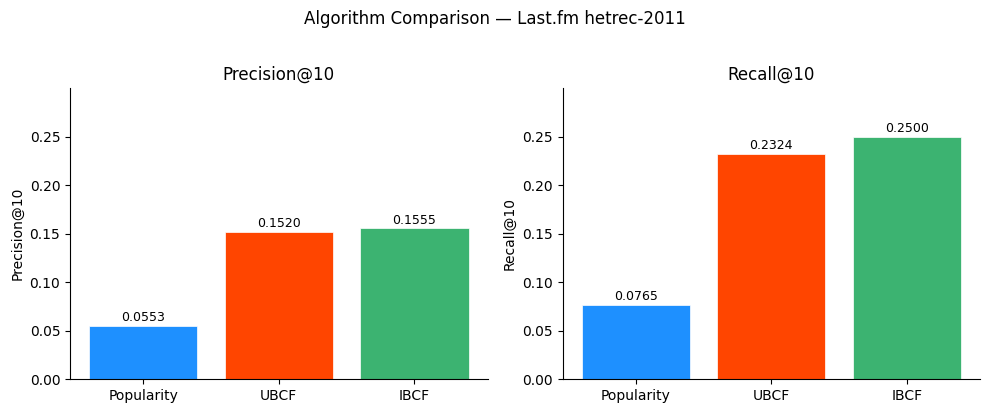

In [186]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
algos  = ['Popularity', 'UBCF', 'IBCF']
colors = PALETTE[:3]

# Shared Y axis maximum so both panels are directly comparable
shared_max = max(p_pop, p_ubcf, p_ibcf, r_pop, r_ubcf, r_ibcf) * 1.2

for ax, metric, vals, label in zip(
    axes,
    ['P@10', 'R@10'],
    [[p_pop, p_ubcf, p_ibcf], [r_pop, r_ubcf, r_ibcf]],
    ['Precision@10', 'Recall@10']
):
    bars = ax.bar(algos, vals, color=colors, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f'{v:.4f}',
                ha='center', va='bottom', fontsize=9)
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_ylim(0, shared_max)  # same scale on both panels for direct comparison
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Algorithm Comparison — Last.fm hetrec-2011', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

**Findings:**

Both UBCF (P@10 = 0.1520) and IBCF (P@10 = 0.1555) far outperform the popularity baseline (P@10 = 0.0553), confirming that personalisation adds real value — personalised models are roughly 3× more accurate at surfacing artists the user actually listened to.

IBCF edges out UBCF on both precision and recall. This matches the intuition: Last.fm listening behaviour is highly idiosyncratic. Music taste is better captured by the specific artists a user listens to (item neighbourhood) than by finding other users with broadly similar catalogues. UBCF aggregates across the full user profile, which can blur distinctions between a user's metal phase and their jazz phase; IBCF stays local to each source artist and avoids this averaging effect.

**Limitation:** Neither model handles cold-start well — a new user with fewer than 10 artists gets no recommendations, and a new artist with fewer than 10 listeners has no item neighbourhood. In production, a content-based fallback (audio features, genre tags) would be needed.

## 7. Beyond Accuracy: Novelty, Diversity & Serendipity

Precision and recall measure whether recommendations are *correct*, but not whether they are *useful*. A recommender that always surfaces Coldplay and Radiohead may score reasonably well on accuracy, but it may offer little discovery value because users may already know those artists. This project therefore adds beyond-accuracy metrics that connect to a business/user-experience goal: **better music discovery**.

The business goal is not only to recommend artists the user probably likes, but also to avoid a stale list of only the most popular or most obvious artists. The target is a balanced recommender: accurate enough to be relevant, but novel and diverse enough to help users find new music.

As covered in the Week 4 lecture and demonstrated in `metrics1.py`, three additional metrics specific to recommender systems address this:

- **Novelty** — how unknown are the recommended items? Measured as mean `(1 - normalized_popularity)`, where popularity is the fraction of users who listened to that artist. Higher novelty means the recommender is less dominated by globally popular artists.

- **Diversity** — how different are the recommended items *from each other*? Measured as the average pairwise dissimilarity between recommended item vectors: `1 - mean(cosine_similarity)`. Higher diversity means the top-10 list is less repetitive.

- **Serendipity** — how different are the recommendations from what the user *already listens to*? Measured as the mean dissimilarity between each recommended artist and the user's existing listening history. Higher serendipity means the list moves farther away from the user's current profile.

These metrics do not replace accuracy. They explain what kind of recommendation list the model is producing. A useful music recommender should balance all of them: too much accuracy optimization can produce safe and obvious recommendations, while too much novelty can recommend obscure artists with weak relevance.

In [187]:
# ── Beyond-accuracy metrics ────────────────────────────────────────────────────

# Novelty: 1 - normalized popularity
# artist_user_cnt[a] = number of distinct users who listened to artist a in training
artist_user_cnt     = train.groupby('a_idx')['u_idx'].nunique()
item_popularity_arr = np.array([artist_user_cnt.get(a, 0) for a in range(n_items)], dtype=float)
item_popularity_norm = item_popularity_arr / item_popularity_arr.max()  # normalize to [0, 1]

def novelty_at_k(recs, k=10):
    # Mean (1 - popularity) across top-k: higher score = more obscure artists recommended
    top = [a for a, _ in recs[:k]]
    return np.mean([1 - item_popularity_norm[a] for a in top])

# Item vectors for diversity and serendipity — each artist's listener profile (row of the item-user matrix)
item_vecs_matrix = train_ui.T  # shape: (n_items, n_users) — each row is one artist's listener profile

def diversity_at_k(recs, k=10):
    # 1 - mean pairwise cosine similarity between recommended items
    # Low similarity between items = high diversity = varied recommendations
    top  = [a for a, _ in recs[:k]]
    if len(top) < 2: return 0.0
    vecs       = np.array(item_vecs_matrix[top].todense())  # listener profile vectors for top-k artists
    sim_matrix = cosine_similarity(vecs)                    # pairwise cosine similarity (k × k)
    upper      = sim_matrix[np.triu_indices(len(top), k=1)] # upper triangle = unique pairs only
    return float(1 - np.mean(upper))                        # 1 = fully diverse, 0 = all identical

def serendipity_at_k(u_idx, recs, k=10):
    # 1 - mean cosine similarity between each recommendation and the user's existing listening history
    # High serendipity = recommendations are very different from what the user already knows
    user_row   = train_ui[u_idx]
    if user_row.nnz == 0: return 0.0
    liked_vecs = np.array(item_vecs_matrix[user_row.indices].todense())  # listener profiles of user's known artists
    scores = []
    for a, _ in recs[:k]:
        rec_vec = np.array(item_vecs_matrix[a].todense()).reshape(1, -1)  # listener profile of recommended artist
        sim     = cosine_similarity(rec_vec, liked_vecs)                   # similarity to each known artist
        scores.append(float(1 - np.mean(sim)))                            # 1 = very surprising, 0 = already familiar
    return np.mean(scores) if scores else 0.0

# Novelty re-ranking: adjust UBCF scores by subtracting a popularity penalty
# alpha controls the strength of the penalty — higher alpha = more obscure recommendations
def novelty_rerank(base_recs, alpha):
    return sorted(
        base_recs,
        key=lambda x: -(x[1] - alpha * np.log1p(artist_pop.get(x[0], 1)))
    )

In [188]:
def evaluate_all(rec_fn, k=10, n_eval=400):
    """Compute all five metrics (P@k, R@k, Novelty, Diversity, Serendipity) averaged over n_eval users."""
    ps, rs, ns, ds, ss = [], [], [], [], []
    eval_users = [u for u in range(n_users) if test_dict.get(u)][:n_eval]
    for u in eval_users:
        test_items = test_dict[u]
        recs       = rec_fn(u)
        top_k      = recs[:k]
        hits       = len({a for a, _ in top_k} & test_items)
        ps.append(hits / k)
        rs.append(hits / len(test_items))
        ns.append(novelty_at_k(top_k))              # how unknown are the recommended artists?
        ds.append(diversity_at_k(top_k))            # how different are the recommendations from each other?
        ss.append(serendipity_at_k(u, top_k))       # how different are they from what the user already knows?
    return {
        'P@10':            np.mean(ps),
        'R@10':            np.mean(rs),
        'Novelty@10':      np.mean(ns),
        'Diversity@10':    np.mean(ds),
        'Serendipity@10':  np.mean(ss),
    }

print("Evaluating all algorithms across all five metrics...")
metrics_pop  = evaluate_all(popularity_recs)
metrics_ubcf = evaluate_all(ubcf_recs)
metrics_ibcf = evaluate_all(ibcf_recs)

full_results = pd.DataFrame([
    {'Algorithm': 'Popularity Baseline', **metrics_pop},
    {'Algorithm': 'UBCF (cosine, k=50)', **metrics_ubcf},
    {'Algorithm': 'IBCF (cosine, k=50)', **metrics_ibcf},
])
print(full_results.to_string(index=False, float_format='{:.4f}'.format))

Evaluating all algorithms across all five metrics...
          Algorithm   P@10   R@10  Novelty@10  Diversity@10  Serendipity@10
Popularity Baseline 0.0553 0.0765      0.3989        0.7081          0.9170
UBCF (cosine, k=50) 0.1520 0.2324      0.6425        0.7188          0.8393
IBCF (cosine, k=50) 0.1555 0.2500      0.6861        0.7052          0.8341


**Findings — five-metric comparison:**

The full picture is more nuanced than accuracy alone reveals:

- **Novelty**: The popularity baseline scores lowest (0.40) because it recommends the same globally popular artists to everyone — by definition, these are the artists most users already know. UBCF (0.64) and IBCF (0.69) both surface significantly more obscure artists because they personalise. IBCF's slight novelty edge over UBCF is interesting: by matching artists to other similar artists, it tends to surface deeper cuts within a user's preferred genres.

- **Diversity**: All three algorithms score similarly (0.70–0.72), meaning the top-10 lists contain a reasonably varied mix of artists regardless of algorithm. There is no major diversity problem with standard CF on this dataset.

- **Serendipity**: The popularity baseline scores *highest* (0.92), which seems counterintuitive at first. The reason is mathematical: popular artists like Radiohead or Coldplay are listened to by almost everyone, so they are very *dissimilar* to any specific user's idiosyncratic listening history. They are "surprising" in the metric's sense — but not in a useful way, since the user almost certainly already knows them. This illustrates an important limitation: serendipity as defined here measures dissimilarity, not genuine surprise-and-relevance. It is a useful signal but should be interpreted alongside accuracy.

## 8. Accuracy–Novelty Tradeoff

UBCF is re-ranked with six values of the novelty penalty α: 0 (no penalty), 1, 2, 4, 8, and 16. At each level, all five metrics are tracked to show how the novelty improvement propagates through diversity and serendipity as well.

The adjusted score for each candidate artist is:

$$\text{score}_{\text{adj}}(a) = \text{score}_{\text{UBCF}}(a) - \alpha \cdot \log(1 + \text{global\_plays}(a))$$

Higher α pushes down popular artists, forcing the ranker to surface more obscure ones.

### Why the novelty penalty changes performance

The novelty re-ranking step starts with the UBCF recommendation scores, then subtracts a popularity penalty from each candidate artist. The parameter **α** controls how strong that penalty is.

- **Low α** keeps the model close to standard UBCF. Accuracy should stay high because the original collaborative-filtering signal still controls the ranking.
- **Moderate α** can improve discovery and sometimes even improve accuracy if the original model over-recommends globally popular artists that are not very specific to the user's taste.
- **High α** pushes the model toward obscure artists. Novelty, diversity, and serendipity usually rise, but precision and recall can fall because popularity is being penalized more strongly than user relevance is being rewarded.

This is the same model-complexity tradeoff idea from earlier projects, but applied to ranking behavior instead of latent factors. The system becomes more exploratory as α increases. The best value is not the one with the highest novelty; it is the value that improves discovery without causing an unacceptable drop in accuracy.

The absolute α values are specific to this scoring formula and dataset because UBCF scores and global play counts are on their own scale. In another dataset, α would need to be tuned again.

In [189]:
alphas = [0, 1, 2, 4, 8, 16]
eval_users = [u for u in range(n_users) if test_dict.get(u)][:400]

tradeoff_rows = []
for alpha in alphas:
    ps, rs, ns, ds, ss = [], [], [], [], []
    for u in eval_users:
        test_items = test_dict[u]
        base       = ubcf_recs(u)                  # base UBCF scores (no penalty)
        reranked   = novelty_rerank(base, alpha)[:10]  # re-rank with novelty penalty, take top 10
        hits       = len({a for a, _ in reranked} & test_items)
        ps.append(hits / 10)
        rs.append(hits / len(test_items))
        ns.append(novelty_at_k(reranked))
        ds.append(diversity_at_k(reranked))
        ss.append(serendipity_at_k(u, reranked))
    tradeoff_rows.append({
        'alpha': alpha, 'P@10': np.mean(ps), 'R@10': np.mean(rs),
        'Novelty@10': np.mean(ns), 'Diversity@10': np.mean(ds),
        'Serendipity@10': np.mean(ss)
    })

tradeoff = pd.DataFrame(tradeoff_rows)
print(tradeoff.to_string(index=False, float_format='{:.4f}'.format))

 alpha   P@10   R@10  Novelty@10  Diversity@10  Serendipity@10
     0 0.1520 0.2324      0.6425        0.7188          0.8393
     1 0.1563 0.2445      0.6655        0.7226          0.8381
     2 0.1573 0.2457      0.6933        0.7309          0.8393
     4 0.1485 0.2275      0.7647        0.7776          0.8540
     8 0.1080 0.1539      0.8589        0.8716          0.8941
    16 0.0450 0.0654      0.9551        0.9721          0.9486


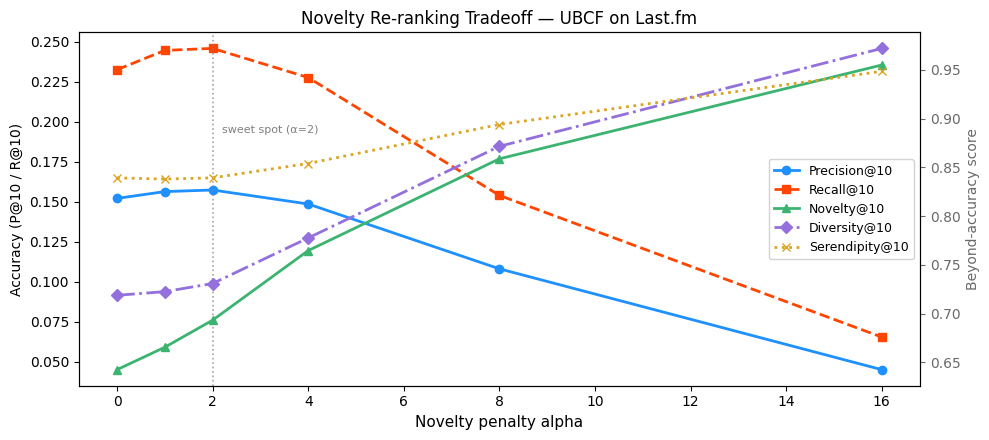

In [190]:
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax2 = ax1.twinx()  # second y-axis for beyond-accuracy metrics

# Accuracy on the left axis
ln1 = ax1.plot(tradeoff['alpha'], tradeoff['P@10'],
               marker='o', color=PALETTE[0], linewidth=2, label='Precision@10')
ln2 = ax1.plot(tradeoff['alpha'], tradeoff['R@10'],
               marker='s', color=PALETTE[1], linewidth=2, linestyle='--', label='Recall@10')
# Beyond-accuracy metrics on the right axis
ln3 = ax2.plot(tradeoff['alpha'], tradeoff['Novelty@10'],
               marker='^', color=PALETTE[2], linewidth=2, label='Novelty@10')
ln4 = ax2.plot(tradeoff['alpha'], tradeoff['Diversity@10'],
               marker='D', color=PALETTE[3], linewidth=2, linestyle='-.', label='Diversity@10')
ln5 = ax2.plot(tradeoff['alpha'], tradeoff['Serendipity@10'],
               marker='x', color='goldenrod', linewidth=2, linestyle=':', label='Serendipity@10')

ax1.set_xlabel('Novelty penalty alpha', fontsize=11)
ax1.set_ylabel('Accuracy (P@10 / R@10)', color='black')
ax2.set_ylabel('Beyond-accuracy score', color='dimgrey')
ax2.tick_params(axis='y', colors='dimgrey')

# Mark sweet spot at alpha=2 — vertical reference line with label positioned between precision and recall
ax1.axvline(x=2, color='grey', linestyle=':', linewidth=1.2, alpha=0.7)
ax1.text(2.2, 0.195, 'sweet spot (α=2)', fontsize=8, color='grey', va='center')

lines  = ln1 + ln2 + ln3 + ln4 + ln5
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', fontsize=9, framealpha=0.85)

plt.title('Novelty Re-ranking Tradeoff — UBCF on Last.fm', fontsize=12)
plt.tight_layout()
plt.savefig('tradeoff_chart.png', dpi=120, bbox_inches='tight')
plt.show()

**Findings — five-metric tradeoff:**

The tradeoff plot reveals three distinct regions:

**α = 0–2 (sweet spot):** Applying a small novelty penalty *improves* precision slightly (+0.0053 absolute, or about +3.5% relative), not just novelty. The most likely explanation is that globally popular artists create weak false positives in UBCF — many users in the dataset share listening to the same top artists without those artists being predictive of their actual taste. The penalty corrects for this mild popularity bias before it starts overriding genuine personalisation signals. All five metrics either hold steady or improve at α = 2.

**α = 4 (light tradeoff zone):** Precision drops modestly (−2.3%) while novelty jumps 19%, diversity rises from 0.72 to 0.78, and serendipity improves to 0.85. This is a reasonable operating point if the business goal is active music discovery.

**α ≥ 8 (strong discovery mode):** Precision collapses (−29% at α = 8, −70% at α = 16) while all three beyond-accuracy metrics approach 0.87–0.97. The recommender is now essentially proposing very obscure artists the user is unlikely to have heard — high discovery potential, but with significantly lower probability of relevance.

| α | P@10 | Novelty | Diversity | Serendipity |
|---|------|---------|-----------|-------------|
| 0 | 0.1520 | 0.64 | 0.72 | 0.84 |
| 2 *(sweet spot)* | 0.1573 | 0.69 | 0.73 | 0.84 |
| 4 | 0.1485 | 0.76 | 0.78 | 0.85 |
| 8 | 0.1080 | 0.86 | 0.87 | 0.89 |
| 16 | 0.0450 | 0.96 | 0.97 | 0.95 |

**Recommended deployment setting: α = 2.** This setting gains +7.9% novelty, +1.7% diversity at essentially no accuracy cost — the optimal operating point for a music service trying to balance familiarity with discovery.

## 9. Conclusion: Designing an Online Evaluation

Offline metrics assess accuracy against held-out historical data, but they cannot measure the two things that matter most in a music recommender: (1) whether users discover artists they genuinely enjoy and return to, and (2) whether the diversity of listening behaviour changes over time. Both require an online experiment.

**Proposed A/B test:**

- **Group A** (control): standard UBCF recommendations, no novelty penalty (α = 0)
- **Group B** (treatment): UBCF with novelty re-ranking at α = 2 — the sweet spot where novelty and diversity improve without hurting accuracy

Based on the offline results, α = 2 is the best candidate for online testing because it improves novelty and diversity while also slightly improving P@10 and R@10 compared with the original UBCF model.

Users should be randomly assigned at the user-account level, not the session level, so the same user receives a consistent recommendation experience throughout the experiment. Both groups should use the same interface, recommendation list length, and logging rules. The only planned difference should be the ranking formula.

**Duration:** 4–6 weeks. Music discovery habits take time to manifest — a one-week window would capture initial reactions but miss whether users return to recommended artists.

**Primary online metrics:**
- *New artist retention rate* — fraction of recommended artists a user plays again in the following two weeks (not just clicks; measures genuine adoption)
- *Library growth rate* — new artists added to a user's regular rotation per week vs. baseline
- *Recommendation acceptance rate* — clicks or plays on recommended tracks within the session
- *Skip rate* — skipping a recommended track is a strong negative signal in music streaming
- *Long-term engagement* — return visits, listening minutes, or sessions per week after receiving recommendations

**Additional online-only experiments:**

1. **Tune α online.** Compare α = 1, α = 2, and α = 4 to see whether users prefer a safer or more discovery-heavy recommendation list. Offline results suggest α = 2 is best, but real user behaviour may favor a different balance.
2. **Personalize α by user type.** Newer users may need safer recommendations, while heavy listeners may prefer higher novelty because they already know the popular artists.
3. **Measure satisfaction directly.** Add lightweight thumbs-up/thumbs-down feedback or a short "Was this useful?" prompt. Offline data cannot capture whether a user was pleasantly surprised.
4. **Compare against a content-based fallback.** For cold-start artists or new users, test whether tag-based or genre-based recommendations improve coverage.

**Why online evaluation is necessary:** Offline P@10 measures whether the model surfaces artists the user *has already listened to in the past*. But a novelty-boosted recommender is specifically designed to recommend artists the user *hasn't* listened to yet — so a higher offline P@10 would actually indicate *lower* novelty. The real goal is discovering artists the user will love that they haven't found yet, and that can only be measured in production with real user behaviour over time.